In [ ]:
import pandas as pd
import numpy as np

# Raw e-commerce data with missing values (np.nan)
data = {
    'Product': ['Laptop', 'Mouse', 'Keyboard', 'Monitor', 'Headphones'],
    'Price': [1200.0, 25.0, np.nan, 300.0, 80.0],
    'Quantity_Sold': [15, 120, 45, np.nan, 60]
}

df = pd.DataFrame(data)
print("--- Raw Data ---")
print(df)

df['Price'] = df['Price'].fillna(df['Price'].median())
df['Quantity_Sold'] = df['Quantity_Sold'].fillna(0)

array = np.array([df['Price'],df['Quantity_Sold']])

revenue_data = {
    'Product': ['Laptop', 'Mouse', 'Keyboard', 'Monitor', 'Headphones'], 
    'Revenue': array[0] * array[1, :]
}
total_revnue = pd.DataFrame(revenue_data)
print("--- Filled Data ---")
print(df)
print("--- Math ---")
print(f"{array} \n")
print(array[0] * array[1, :])
print("--- Result ---")
print(total_revnue)

--- Raw Data ---
      Product   Price  Quantity_Sold
0      Laptop  1200.0           15.0
1       Mouse    25.0          120.0
2    Keyboard     NaN           45.0
3     Monitor   300.0            NaN
4  Headphones    80.0           60.0
--- Filled Data ---
      Product   Price  Quantity_Sold
0      Laptop  1200.0           15.0
1       Mouse    25.0          120.0
2    Keyboard   190.0           45.0
3     Monitor   300.0            0.0
4  Headphones    80.0           60.0
--- Math ---
[[1200.   25.  190.  300.   80.]
 [  15.  120.   45.    0.   60.]] 

[18000.  3000.  8550.     0.  4800.]
--- Result ---
      Product  Revenue
0      Laptop  18000.0
1       Mouse   3000.0
2    Keyboard   8550.0
3     Monitor      0.0
4  Headphones   4800.0


In [5]:
import pandas as pd
import numpy as np

# Student data with missing values
data = {
    'Student': ['Emma', 'Liam', 'Olivia', 'Noah', 'Ava'],
    'Math_Score': [88, np.nan, 72, 95, 60],
    'Science_Score': [90, 85, np.nan, 92, 55]
}

df = pd.DataFrame(data)
filled_data = pd.DataFrame(data)
filled_data['Math_Score'] = filled_data['Math_Score'].fillna(df['Math_Score'].mean())
filled_data['Science_Score'] = filled_data['Science_Score'].fillna(df['Science_Score'].mean())

math_scores = np.array(filled_data['Math_Score'])
scinece_scores = np.array(filled_data['Science_Score'])

student_scores = (math_scores + scinece_scores) / 2

print("--- Original Data ---")
print(df)

print("--- New Data ---")
print(filled_data)

scores = {
    'Student': ['Emma', 'Liam', 'Olivia', 'Noah', 'Ava'],
    'Score': student_scores
}

scores_frame = pd.DataFrame(scores)

print("--- Student Avrages ---")
print(scores_frame)

--- Original Data ---
  Student  Math_Score  Science_Score
0    Emma        88.0           90.0
1    Liam         NaN           85.0
2  Olivia        72.0            NaN
3    Noah        95.0           92.0
4     Ava        60.0           55.0
--- New Data ---
  Student  Math_Score  Science_Score
0    Emma       88.00           90.0
1    Liam       78.75           85.0
2  Olivia       72.00           80.5
3    Noah       95.00           92.0
4     Ava       60.00           55.0
--- Student Avrages ---
  Student   Score
0    Emma  89.000
1    Liam  81.875
2  Olivia  76.250
3    Noah  93.500
4     Ava  57.500


In [13]:
import pandas as pd
import numpy as np

data = {
    'City': ['Vancouver', 'Toronto', 'Montreal', 'Calgary', 'Ottawa'],
    'Temp_Celsius': [18.5, np.nan, 22.0, 15.5, np.nan]
}

df = pd.DataFrame(data)
print("--- Original Data ---")
print(df)


df['Temp_Celsius'] = df['Temp_Celsius'].fillna(df['Temp_Celsius'].mean())
df['Temp_Fahrenheit'] = (df['Temp_Celsius'] * (9/5)) + 32

print("--- New Data ---")
print(df)


--- Original Data ---
        City  Temp_Celsius
0  Vancouver          18.5
1    Toronto           NaN
2   Montreal          22.0
3    Calgary          15.5
4     Ottawa           NaN
--- New Data ---
        City  Temp_Celsius  Temp_Fahrenheit
0  Vancouver     18.500000             65.3
1    Toronto     18.666667             65.6
2   Montreal     22.000000             71.6
3    Calgary     15.500000             59.9
4     Ottawa     18.666667             65.6


In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression

data = {
    'Hours_Studied': [1, 2, 3, 4, 5],
    'Exam_Score': [50, 60, 70, 80, 90]
}
df = pd.DataFrame(data)
x, y = df['Hours_Studied'], df['Exam_Score']

model = LinearRegression()
model.fit(x.values.reshape(-1, 1), y)

print("Model Training Complete")

predicted_score = model.predict([[6]])
print(f"Predicted Exam Score for 6 hours of study: {predicted_score}")

Model Training Complete
Predicted Exam Score for 6 hours of study: [100.]


In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

data = {
    'Hours_Studied': [1, 2, 3, 4, 5, 6, 7, 8],
    'Hours_Slept': [5, 6, 7, 8, 5, 7, 8, 9],
    'Exam_Score': [52, 64, 76, 88, 65, 82, 91, 98]
}

df = pd.DataFrame(data)

X = df[['Hours_Studied', 'Hours_Slept']]
y = df['Exam_Score']

# 1. Split the data: 75% for training, 25% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 2. Train the model ONLY on the training data
model = LinearRegression()
model.fit(X_train, y_train)

# 3. Test the model on the unseen test data
predictions = model.predict(X_test)

# 4. Score the model's accuracy
score = r2_score(y_test, predictions)
print(f"Model R^2 Accuracy Score: {score}")

Model R^2 Accuracy Score: 0.9846432084085671


In [1]:
import pandas as pd
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
data = {
    'Square_Feet': [1200, 1500, 1800, 2000, 2400, 2800, 3000, 3500],
    'Bedrooms': [2, 3, 3, 4, 4, 5, 5, 5],
    'Price': [250000, 300000, 350000, 400000, 470000, 540000, 580000, 670000]
}

df = pd.DataFrame(data)
X = df[['Square_Feet', 'Bedrooms']]
y = df['Price']

train_x, test_x, train_y, test_y = train_test_split(X, y, test_size= 0.25)

model = LinearRegression()
model.fit(train_x, train_y)

predictions = model.predict(test_x)
score = r2_score(test_y, predictions)

new_data = test_x
new_data['Predictions'] = predictions.round(2)
new_data['Price'] = test_y

print(new_data)
print(f"Score = {score}")

   Square_Feet  Bedrooms  Predictions   Price
7         3500         5    671356.47  670000
2         1800         3    359148.26  350000
Score = 0.9983294774490242


In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

data = {
    'Car_Age_Years': [1, 2, 3, 5, 6, 8, 10],
    'Mileage_Thousands': [10, 25, 40, 60, 75, 110, 140],
    'Price_Thousands': [28, 24, 21, 16, 14, 9, 6]
}

df = pd.DataFrame(data)
print(df)

X = df[['Car_Age_Years', 'Mileage_Thousands']]
y = pd.Series(data['Price_Thousands'])

train_x, test_x, train_y, test_y = train_test_split(X, y, test_size=.25, random_state=None)
model = LinearRegression()
model.fit(train_x, train_y)

predictions = model.predict(test_x)
new_data = {
    'Car_Age_Years': test_x['Car_Age_Years'],
    'Mileage_Thousands': test_x['Mileage_Thousands'],
    'Predictions': predictions
}

new_frame = pd.DataFrame(new_data)
score = r2_score(test_y, predictions)
print(new_frame)
print(score)



   Car_Age_Years  Mileage_Thousands  Price_Thousands
0              1                 10               28
1              2                 25               24
2              3                 40               21
3              5                 60               16
4              6                 75               14
5              8                110                9
6             10                140                6
   Car_Age_Years  Mileage_Thousands  Predictions
1              2                 25    24.526316
3              5                 60    16.421053
0.9858033240997229


In [4]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

# 1. Load and split data
digits = load_digits()
X, y = digits.data, digits.target
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Train model
model = LogisticRegression(max_iter=10000)
model.fit(x_train, y_train)

# 3. Predict and evaluate
predictions = model.predict(x_test)

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, predictions)
print("Confusion Matrix:")
print(conf_matrix)

# Generate a clean report of Precision and Recall per digit
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Confusion Matrix:
[[53  0  0  0  0  0  0  0  0  0]
 [ 0 47  1  0  0  0  0  0  2  0]
 [ 0  0 47  0  0  0  0  0  0  0]
 [ 0  0  1 52  0  1  0  0  0  0]
 [ 0  1  0  0 58  0  1  0  0  0]
 [ 0  1  0  0  0 63  1  0  0  1]
 [ 0  0  0  0  0  1 52  0  0  0]
 [ 0  0  0  0  0  1  0 53  0  1]
 [ 0  0  0  0  0  1  0  0 42  0]
 [ 0  0  0  1  0  0  0  0  2 56]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       0.96      0.94      0.95        50
           2       0.96      1.00      0.98        47
           3       0.98      0.96      0.97        54
           4       1.00      0.97      0.98        60
           5       0.94      0.95      0.95        66
           6       0.96      0.98      0.97        53
           7       1.00      0.96      0.98        55
           8       0.91      0.98      0.94        43
           9       0.97      0.95      0.96        59

    accuracy                   

In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

digits = load_digits()
X, y = digits.data, digits.target
model = LogisticRegression(max_iter=10000)
for num in range(1, 9):
    
    train_x, test_x, train_y, test_y = train_test_split(X, y, test_size=num / 10)
    model.fit(train_x, train_y)

    predictions = model.predict(test_x)
    confusion = confusion_matrix(test_y, predictions)
    score = accuracy_score(test_y, predictions)
    print(f"\n Test size: {num /10}, \n{confusion} \n Acuracy: {score}, ")


 Test size: 0.1, 
[[23  0  0  0  0  0  0  0  0  0]
 [ 0 15  0  1  0  0  0  0  0  0]
 [ 0  0 15  0  0  0  0  0  0  0]
 [ 0  0  0 16  0  0  0  0  0  0]
 [ 0  0  0  0 18  0  0  0  0  0]
 [ 0  0  0  0  0 13  1  0  0  1]
 [ 0  0  0  0  0  0 14  0  0  0]
 [ 0  0  0  0  0  0  0 20  0  0]
 [ 0  0  0  0  0  0  0  0 25  0]
 [ 0  0  0  0  0  0  0  0  1 17]] 
 Acuracy: 0.9777777777777777, 

 Test size: 0.2, 
[[30  0  0  0  0  1  0  0  0  0]
 [ 0 34  1  0  1  0  0  0  1  2]
 [ 0  0 25  0  0  0  0  0  0  0]
 [ 0  0  0 45  0  1  0  0  1  0]
 [ 0  0  0  0 36  0  0  0  0  0]
 [ 0  1  0  0  0 37  1  1  0  0]
 [ 0  0  0  0  0  0 39  0  0  0]
 [ 0  0  0  0  0  2  0 26  0  1]
 [ 0  1  0  0  0  1  0  1 36  0]
 [ 0  0  0  0  0  0  0  1  0 34]] 
 Acuracy: 0.95, 

 Test size: 0.3, 
[[46  0  0  0  0  2  0  0  0  0]
 [ 0 51  0  0  0  0  0  0  0  1]
 [ 0  1 51  0  0  0  0  0  0  0]
 [ 0  0  0 50  0  1  0  0  0  0]
 [ 0  0  0  0 55  0  0  0  0  1]
 [ 0  0  0  0  0 54  0  0  0  1]
 [ 0  0  0  0  0  0 61  0  0  0]


Digit 0 Precision: 0.50
Digit 1 Precision: 1.00
Digit 2 Precision: 1.00
Digit 3 Precision: 0.50
Digit 4 Precision: 1.00
Digit 5 Precision: 1.00
Digit 6 Precision: 1.00
Digit 7 Precision: 1.00
Digit 8 Precision: 1.00


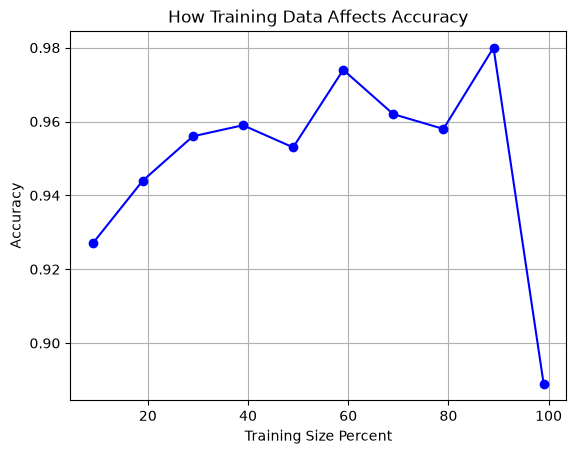

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_digits
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score
import matplotlib.pyplot as plt


X, y = load_digits(return_X_y=True)
model = LogisticRegression(max_iter=10000)
accuracy_list = []
training_percents = []
for num in range(0, 10):
    train_percent = num / 10 + 0.09
    train_x, test_x, train_y, test_y = train_test_split(X, y, train_size=train_percent)
    model.fit(train_x, train_y)
    predictions = model.predict(test_x)
    confusion = confusion_matrix(test_y, predictions)
    score = accuracy_score(test_y, predictions)
    accuracy_list.append(round(score, 3))
    training_percents.append(round(train_percent, 2) * 100)
    #print(f"\n Training Percent: {train_percent} \n {confusion} \n Accuracy: {score}")

# Pass average=None to get a score for every single digit (0 through 9)
precisions = precision_score(test_y, predictions, average=None)

for digit, score in enumerate(precisions):
  print(f"Digit {digit} Precision: {score:.2f}")

plt.plot(training_percents, accuracy_list, marker="o", color="blue")
plt.xlabel("Training Size Percent")
plt.ylabel("Accuracy")
plt.title("How Training Data Affects Accuracy")
plt.grid()
plt.show(True)





In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

X, y = load_digits(return_X_y=True)

train_x, test_x, train_y, test_y = train_test_split(X, y, test_size=0.3)

model = LogisticRegression(max_iter=10000)
model.fit(train_x, train_y)

predictions = model.predict(test_x)
confusion = confusion_matrix(test_y, predictions)

def Find_Highest_Conf(matrix):
    errors = []
    position = {}
    for row_num in range(len(confusion[0])):
        for colum_num in range(len(confusion)):
            if colum_num != row_num and confusion[row_num][colum_num] != 0:
                errors.append(confusion[row_num][colum_num])
                position[confusion[row_num][colum_num]] = row_num, colum_num

    return f"Largest Mistake Confusing {position[max(errors)][0]}'s as {position[max(errors)][1]}, {max(errors)} times"
print(confusion)

print(Find_Highest_Conf(confusion))

[[ 0.  0.  5. ...  0.  0.  0.]
 [ 0.  0.  0. ... 10.  0.  0.]
 [ 0.  0.  0. ... 16.  9.  0.]
 ...
 [ 0.  0.  1. ...  6.  0.  0.]
 [ 0.  0.  2. ... 12.  0.  0.]
 [ 0.  0. 10. ... 12.  1.  0.]]
[[58  0  0  0  1  0  0  0  0  0]
 [ 0 63  0  0  0  0  0  0  1  0]
 [ 0  0 43  1  0  0  0  0  0  0]
 [ 0  0  0 48  0  0  0  0  0  0]
 [ 0  0  0  0 51  0  0  0  0  4]
 [ 0  1  0  0  0 49  0  0  0  0]
 [ 0  1  0  0  0  1 47  0  1  0]
 [ 0  0  0  0  0  0  0 55  0  1]
 [ 0  2  0  0  0  1  1  0 57  0]
 [ 0  0  0  0  0  0  0  0  1 52]]
Largest Mistake Confusing 4's as 9, 4 times


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score

X, y = load_digits(return_X_y=True)
train_x, test_x, train_y, test_y = train_test_split(X, y, test_size=0.2)

model = LogisticRegression(max_iter=10000)
model.fit(train_x, train_y)

predictions = model.predict(test_x)
recall = recall_score(test_y, predictions, average=None)
weakest = min(recall)
for index, num in enumerate(recall):
    if num == weakest:
        weakest_index = index
    
print(f"Most missed number is {weakest_index}, getting recognized {(weakest * 100):.2f}% of the time")


Most missed number is 5, getting recognized 92.68% of the time


In [42]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# 10,000 total transactions: 9,900 legitimate (0), 100 fraudulent (1)
np.random.seed(42)
y_true = np.array([0]*9900 + [1]*100)

# The current model predicts everything is legitimate (0)
y_pred_lazy = np.zeros_like(y_true)
print(confusion_matrix(y_true, y_pred_lazy))
print(classification_report(y_true, y_pred_lazy))
conf = confusion_matrix(y_true, y_pred_lazy).ravel().tolist()
print(f"false positives: {conf[1]}")
print(f"false negative: {conf[2]}")
print(f"Total cost: {(conf[2]* 2500) + (conf[1] * 50)} dollars")

# print the classification report, and calculate the total financial loss!

[[9900    0]
 [ 100    0]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      9900
           1       0.00      0.00      0.00       100

    accuracy                           0.99     10000
   macro avg       0.49      0.50      0.50     10000
weighted avg       0.98      0.99      0.99     10000

false positives: 0
false negative: 100
Total cost: 250000 dollars


c:\Users\Matthew\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Matthew\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Matthew\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

In [50]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# 50,000 total files: 49,500 safe (0), 500 malware (1)
np.random.seed(42)
y_true = np.array([0]*49500 + [1]*500)

# The current lazy model predicts everything is safe (0)
y_pred_lazy = np.zeros_like(y_true)

conf_matrix = confusion_matrix(y_true, y_pred_lazy)

tn, fp, fn, tp = conf_matrix.ravel()

net_loss = (fn*10000) + (fp*200)


print(conf_matrix)
print(classification_report(y_true, y_pred_lazy))
print(f"Dangerous files let in (False Negatives): {fn}")
print(f"Harmless files blocked (False Positives): {fp}")
print(f"Total Loss = ${net_loss:,}")

[[49500     0]
 [  500     0]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     49500
           1       0.00      0.00      0.00       500

    accuracy                           0.99     50000
   macro avg       0.49      0.50      0.50     50000
weighted avg       0.98      0.99      0.99     50000

Dangerous files let in (False Negatives): 500
Harmless files blocked (False Positives): 0
Total Loss = $5,000,000


c:\Users\Matthew\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Matthew\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Matthew\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer


df = pd.read_csv("spam_dataset.csv")

X, y = df['message_content'], df['is_spam']
train_x, test_x, train_y, test_y = train_test_split(X, y, train_size=0.3)

vectorizer = TfidfVectorizer()

model = LogisticRegression(max_iter=10000)
#pipline = Pipeline([
#    ("vectorizer", vectorizer),
#    ("model", model)
#])
vec_train_x = vectorizer.fit_transform(train_x)
vec_test_x = vectorizer.transform(test_x)

model.fit(vec_train_x, train_y)

#print(train_x)
pred_y = model.predict(vec_test_x)
print(confusion_matrix(test_y, pred_y))
print(classification_report(test_y, pred_y))

[[364   0]
 [  0 336]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       364
           1       1.00      1.00      1.00       336

    accuracy                           1.00       700
   macro avg       1.00      1.00      1.00       700
weighted avg       1.00      1.00      1.00       700



In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.compose import ColumnTransformer
import pandas as pd
import numpy as np
X, y = fetch_openml("titanic",as_frame=True, version=1, return_X_y=True)
y = y.astype(int)

features = ['pclass', 'sex', 'age', 'fare', 'embarked']
X = X[features]

train_x, test_x, train_y, test_y = train_test_split(X, y, test_size=0.3)
scaler = StandardScaler()
num_imputer = SimpleImputer(strategy='median')
str_imputer = SimpleImputer(fill_value='missing', strategy='constant')
onehot = OneHotEncoder(handle_unknown='ignore')
preprocesor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', num_imputer),
            ('scaler', scaler),
        ]), ['pclass', 'age', 'fare']),

        ('cat', Pipeline( [
            ('imputer', str_imputer),
            ('onehot', onehot),
        ]), ['sex', 'embarked'])
    ]
)

pipeline = Pipeline([
    ('preprocessor', preprocesor),
    ('model', LogisticRegression(max_iter=10000))
])


pipeline.fit(train_x, train_y)
pred = pipeline.predict(test_x)
print(pred)
print(confusion_matrix(test_y, pred))
print(classification_report(test_y, pred))

[1 0 1 1 1 1 1 1 0 0 1 0 0 0 0 1 1 0 1 1 1 0 1 0 1 0 0 1 1 0 0 1 1 0 0 0 0
 1 0 0 0 1 1 1 0 1 1 0 0 1 0 1 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 1 1 0 1 0 0 1
 0 0 1 0 1 1 1 0 0 1 0 1 1 1 1 1 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 1 1 0 1 0 1 1 0 0 0 1 0 0 0 1 1 0 1 1 0 0 1 0 0 0 0 0 0 0 0 1 0 1 1 0
 0 1 1 1 1 0 0 1 1 0 0 0 1 1 1 0 1 0 0 1 0 0 0 0 0 0 0 1 1 0 0 0 0 1 1 0 1
 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 1 1 1 1 1 1 0 1 0 1 1 0 1 0 0 1 0 1
 0 0 1 0 0 1 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0
 0 1 1 1 1 0 1 1 0 0 0 0 0 0 1 1 1 1 0 0 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 0
 1 0 0 0 1 1 1 1 0 0 1 1 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 0 1 1 0 0 0 0 0
 0 1 0 0 0 0 0 1 0 1 0 0 1 0 0 1 0 1 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 1 1
 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1]
[[205  47]
 [ 35 106]]
              precision    recall  f1-score   support

           0       0.85      0.81      0.83       252
           1       0.69      0.75      0.72       141

    accuracy   